In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv(r"C:\Users\ryang\Data Analysis\Cafe_sales_Analytics\dirty_cafe_sales.csv")

### Data Cleaning

In [7]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3,NaN,3.0,Digital Wallet,NaN,2023-12-02


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [9]:
df.describe(include='all')

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [10]:
df.isna().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [11]:
df.duplicated().sum()

0

In [12]:
df = df.replace(to_replace='UNKNOWN', value='NaN')

In [13]:
df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors='coerce')

In [14]:
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')

In [15]:
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')

In [16]:
df['Total Spent'] = df['Quantity'] * df['Price Per Unit']

In [17]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,NaN,NaN,2023-08-30
9996,TXN_9659401,NaN,3.0,NaN,NaN,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3.0,NaN,NaN,Digital Wallet,NaN,2023-12-02


In [18]:
df['Price Per Unit'] = df['Total Spent'] / df['Quantity']

In [19]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,NaN,NaN,2023-08-30
9996,TXN_9659401,NaN,3.0,NaN,NaN,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3.0,NaN,NaN,Digital Wallet,NaN,2023-12-02


In [20]:
df.groupby("Item")["Price Per Unit"].median()

Item
Cake        3.0
Coffee      2.0
Cookie      1.0
ERROR       3.0
Juice       3.0
NaN         3.0
Salad       5.0
Sandwich    4.0
Smoothie    4.0
Tea         1.5
Name: Price Per Unit, dtype: float64

In [21]:
df["Price Per Unit"] = (
    df.groupby("Item")["Price Per Unit"]
      .transform(lambda x: x.fillna(x.median()))
)

In [22]:
df['Total Spent'] = df['Quantity'] * df['Price Per Unit']

In [23]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,NaN,NaN,2023-08-30
9996,TXN_9659401,NaN,3.0,NaN,NaN,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3.0,1.0,3.0,Digital Wallet,NaN,2023-12-02


In [24]:
df.isna().sum()

Transaction ID         0
Item                 333
Quantity             479
Price Per Unit       333
Total Spent          794
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [25]:
df["Price Per Unit"] = (
    df["Price Per Unit"]
      .fillna(df["Total Spent"] / df["Quantity"])
)

In [26]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2.0,2.0,4.0,NaN,NaN,2023-08-30
9996,TXN_9659401,NaN,3.0,NaN,NaN,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3.0,1.0,3.0,Digital Wallet,NaN,2023-12-02


In [27]:
df = df.dropna()

In [28]:
df.isna().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

In [29]:
df["Transaction Date"] = pd.to_datetime(
    df["Transaction Date"],
    errors="coerce"
)

C:\Users\ryang\AppData\Local\Temp\ipykernel_2512\1990001602.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Transaction Date"] = pd.to_datetime(


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4545 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    4545 non-null   object        
 1   Item              4545 non-null   object        
 2   Quantity          4545 non-null   float64       
 3   Price Per Unit    4545 non-null   float64       
 4   Total Spent       4545 non-null   float64       
 5   Payment Method    4545 non-null   object        
 6   Location          4545 non-null   object        
 7   Transaction Date  4417 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), object(4)
memory usage: 319.6+ KB


In [31]:
df = df[df["Item"].str.strip().str.upper() != "ERROR"]

In [32]:
df = df[df["Item"].str.strip() != "NaN"]

In [34]:
df = df[df['Payment Method'].str.strip().str.upper() != "ERROR"]

In [35]:
df = df[df['Payment Method'].str.strip() != "NaN"]

In [37]:
df = df[df['Location'].str.strip().str.upper() != "ERROR"]

In [38]:
df = df[df['Location'].str.strip() != "NaN"]

In [39]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
10,TXN_2548360,Salad,5.0,5.0,25.0,Cash,Takeaway,2023-11-07
...,...,...,...,...,...,...,...,...
9977,TXN_5548914,Juice,2.0,3.0,6.0,Digital Wallet,In-store,2023-11-04
9979,TXN_9933628,Smoothie,5.0,4.0,20.0,Cash,In-store,2023-07-20
9986,TXN_2858441,Sandwich,2.0,4.0,8.0,Credit Card,In-store,2023-12-14
9991,TXN_3897619,Sandwich,3.0,4.0,12.0,Cash,Takeaway,2023-02-24


In [1431]:
df.to_csv(r"C:\Users\ryang\Data Analysis\Cafe_sales_Analytics\clean_cafe_sales.csv", index=False)

## Data Exploratory

In [73]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11
10,TXN_2548360,Salad,5.0,5.0,25.0,Cash,Takeaway,2023-11-07


In [75]:
# What is the total revenue?
total_revenue = df['Total Spent'].sum()

In [77]:
total_revenue

31618.5

In [79]:
# What is the average transaction value?
avg_transaction = df['Total Spent'].mean()

In [81]:
avg_transaction

8.957082152974504

In [83]:
# How many transactions are recorded?
transactions_count = df['Total Spent'].count()

In [85]:
transactions_count

3530

In [87]:
# Which month generated the highest revenue?
df['Month'] = df['Transaction Date'].dt.month

In [89]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Month
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,9.0
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,5.0
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19,7.0
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,6.0
10,TXN_2548360,Salad,5.0,5.0,25.0,Cash,Takeaway,2023-11-07,11.0


In [91]:
monthly_revenue = df.groupby('Month')['Total Spent'].sum()

In [93]:
monthly_revenue

Month
1.0     3063.5
2.0     2419.5
3.0     2501.0
4.0     2536.5
5.0     2084.5
6.0     2532.5
7.0     2477.0
8.0     2490.5
9.0     2685.5
10.0    2521.5
11.0    2812.5
12.0    2562.0
Name: Total Spent, dtype: float64

In [95]:
highest_month = monthly_revenue.idxmax()
highest_revenue = monthly_revenue.max()

print(f"Highest revenue month: {highest_month}")
print(f"Revenue: {highest_revenue}")

Highest revenue month: 1.0
Revenue: 3063.5


In [97]:
# Which weekday generates the most sales?
df['Weekday'] = df['Transaction Date'].dt.weekday

In [99]:
df

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Month,Weekday
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,9.0,4.0
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,5.0,1.0
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19,7.0,2.0
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,6.0,6.0
10,TXN_2548360,Salad,5.0,5.0,25.0,Cash,Takeaway,2023-11-07,11.0,1.0
...,...,...,...,...,...,...,...,...,...,...
9977,TXN_5548914,Juice,2.0,3.0,6.0,Digital Wallet,In-store,2023-11-04,11.0,5.0
9979,TXN_9933628,Smoothie,5.0,4.0,20.0,Cash,In-store,2023-07-20,7.0,3.0
9986,TXN_2858441,Sandwich,2.0,4.0,8.0,Credit Card,In-store,2023-12-14,12.0,3.0
9991,TXN_3897619,Sandwich,3.0,4.0,12.0,Cash,Takeaway,2023-02-24,2.0,4.0


In [105]:
weekly_revenue = df.groupby('Weekday')['Total Spent'].count()

In [107]:
weekly_revenue

Weekday
0.0    514
1.0    463
2.0    468
3.0    502
4.0    500
5.0    468
6.0    506
Name: Total Spent, dtype: int64

In [1466]:
highest_weekday = weekly_revenue.idxmax()
highest_sales_count = weekly_revenue.max()

print(f"Highest sales weekday: {highest_weekday}")
print(f"Number of sales: {highest_sales_count}")

Highest sales weekday: 0.0
Number of sales: 514


In [1467]:
# Is there a weekend sales pattern?
weekend_revenue = weekly_revenue[weekly_revenue.index > 4]

In [1468]:
weekend_revenue

Weekday
5.0    468
6.0    506
Name: Total Spent, dtype: int64

Looks like weekend sales are highest on Sundays

In [1473]:
# Which items sell the most?
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Month,Weekday
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,9.0,4.0
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,5.0,1.0
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19,7.0,2.0
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,6.0,6.0
10,TXN_2548360,Salad,5.0,5.0,25.0,Cash,Takeaway,2023-11-07,11.0,1.0


In [1474]:
item_sale = df.groupby('Item')['Total Spent'].count()

In [1477]:
item_sale

Item
Cake        432
Coffee      426
Cookie      457
Juice       482
Salad       473
Sandwich    450
Smoothie    388
Tea         422
Name: Total Spent, dtype: int64

In [1479]:
item_sale.sort_values(ascending=False)

Item
Juice       482
Salad       473
Cookie      457
Sandwich    450
Cake        432
Coffee      426
Tea         422
Smoothie    388
Name: Total Spent, dtype: int64

The top 3 highest-selling items are Juice, Salad and Cookies.

In [1482]:
# Which items generate the highest revenue?
item_revenue = df.groupby('Item')['Total Spent'].sum()

In [1484]:
item_revenue

Item
Cake        3990.0
Coffee      2594.0
Cookie      1352.0
Juice       4239.0
Salad       7120.0
Sandwich    5600.0
Smoothie    4760.0
Tea         1963.5
Name: Total Spent, dtype: float64

In [1485]:
item_revenue.sort_values(ascending=False)

Item
Salad       7120.0
Sandwich    5600.0
Smoothie    4760.0
Juice       4239.0
Cake        3990.0
Coffee      2594.0
Tea         1963.5
Cookie      1352.0
Name: Total Spent, dtype: float64

The top 3 highest-revenue generating items are Salad, Sandwich, Smoothie

Products that should be promoted in terms of Revenue Salad, Sandwich and Smoothie

In [1488]:
# Which payment method is most popular?
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Month,Weekday
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,9.0,4.0
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,5.0,1.0
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19,7.0,2.0
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,6.0,6.0
10,TXN_2548360,Salad,5.0,5.0,25.0,Cash,Takeaway,2023-11-07,11.0,1.0


In [1489]:
payment_method = df.groupby('Payment Method')['Total Spent'].count()

In [1494]:
payment_method

Payment Method
Cash              1167
Credit Card       1145
Digital Wallet    1218
Name: Total Spent, dtype: int64

Digital wallet is the most popular payment method.

In [1497]:
# Which location has the highest sales?
location_sales = df.groupby('Location')['Total Spent'].count()

In [1499]:
location_sales

Location
In-store    1766
Takeaway    1764
Name: Total Spent, dtype: int64

In-store location has the highest sales

In [1502]:
# Which location has the lowest revenue?
location_revenue = df.groupby('Location')['Total Spent'].sum()

In [1504]:
location_revenue

Location
In-store    16121.5
Takeaway    15497.0
Name: Total Spent, dtype: float64

Takeaway location generates the lowest revenue

<Axes: xlabel='Month'>

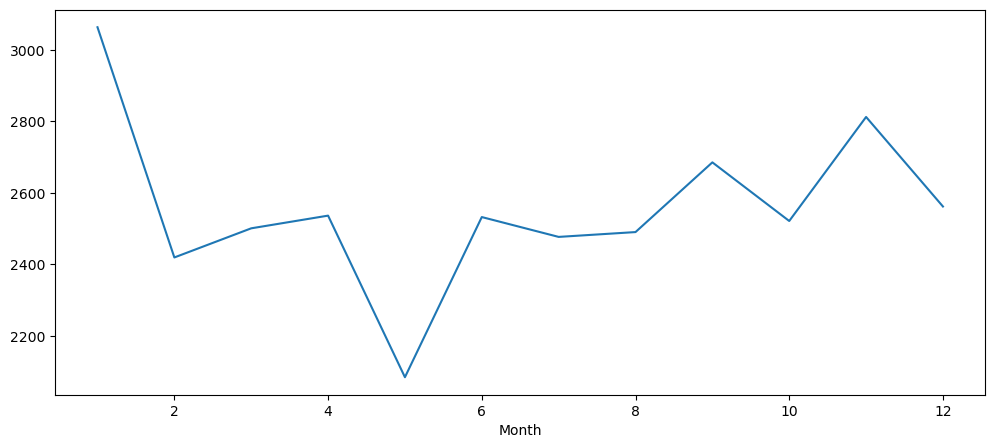

In [1508]:
monthly_revenue = df.groupby('Month')['Total Spent'].sum()
monthly_revenue.plot(figsize=(12,5))

<Axes: xlabel='Item'>

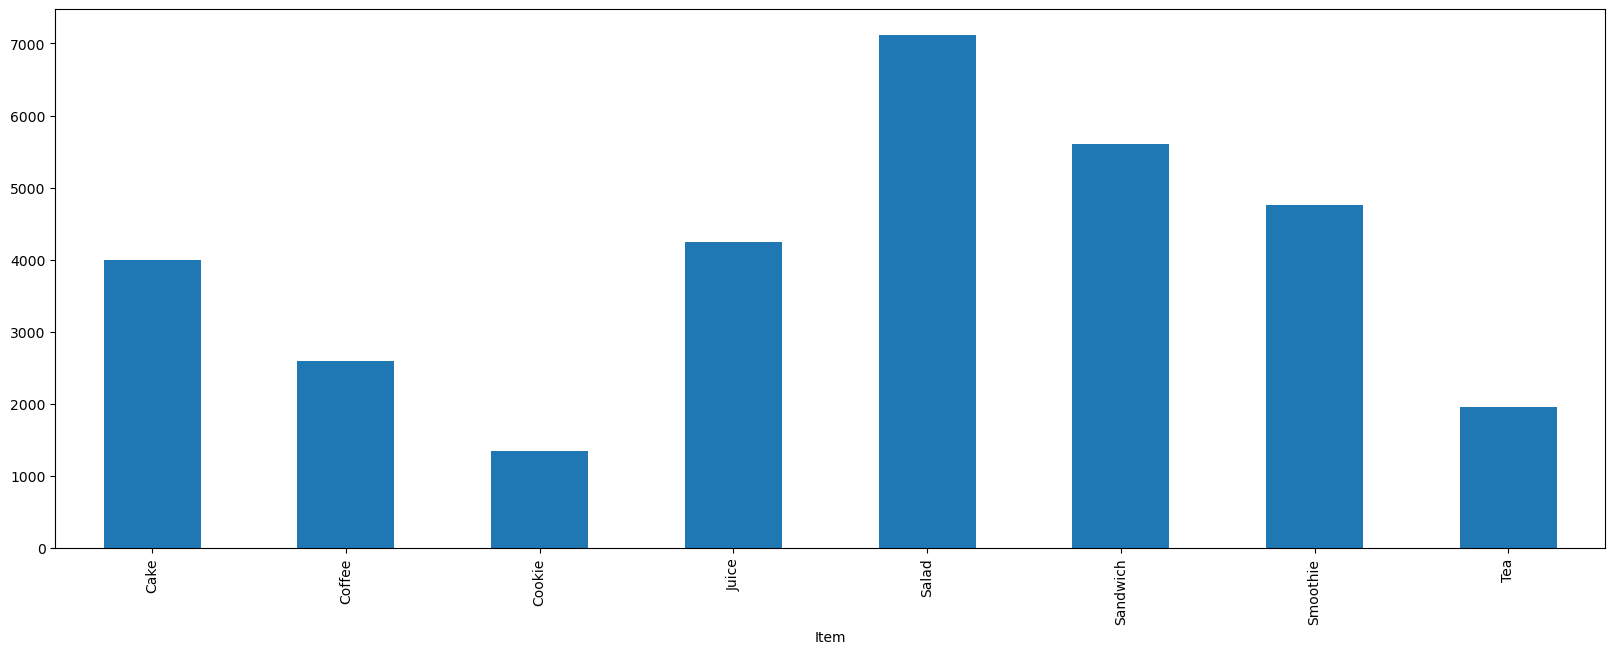

In [1511]:
item_revenue = df.groupby('Item')['Total Spent'].sum()
item_revenue.plot(kind='bar')

<Axes: xlabel='Payment Method'>

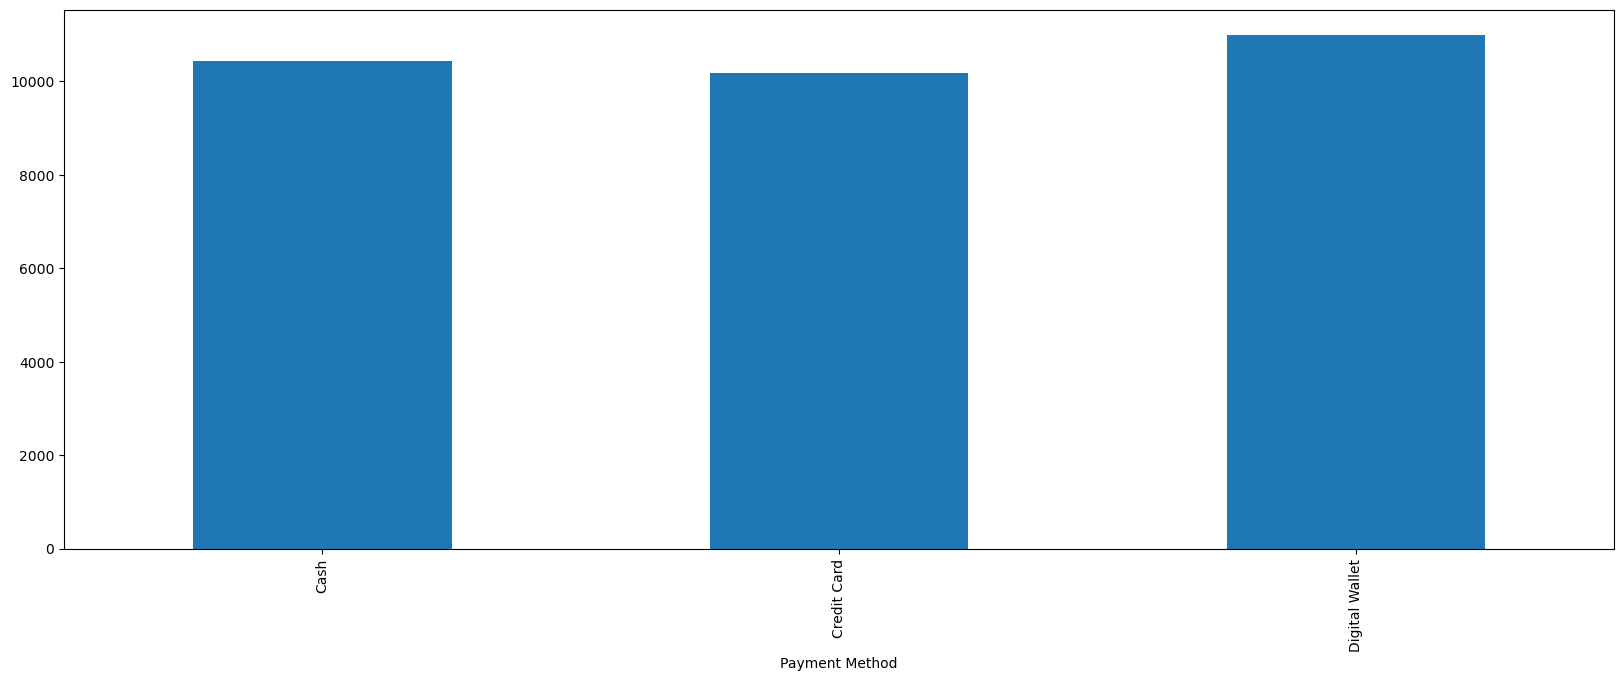

In [1513]:
payment_method_revenue = df.groupby('Payment Method')['Total Spent'].sum()
payment_method_revenue.plot(kind='bar')

<Axes: xlabel='Location'>

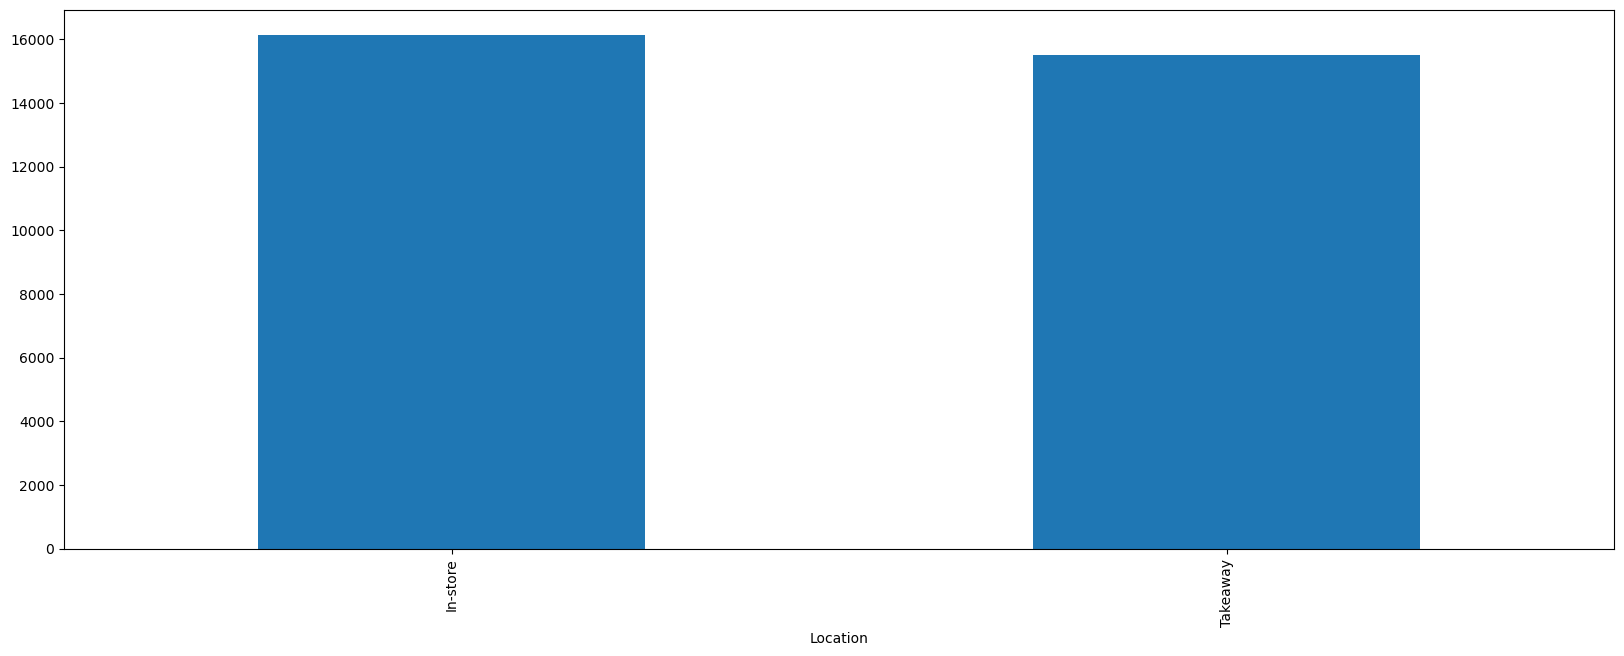

In [1516]:
location_revenue = df.groupby('Location')['Total Spent'].sum()
location_revenue.plot(kind='bar')

Text(0, 0.5, 'Frequency')

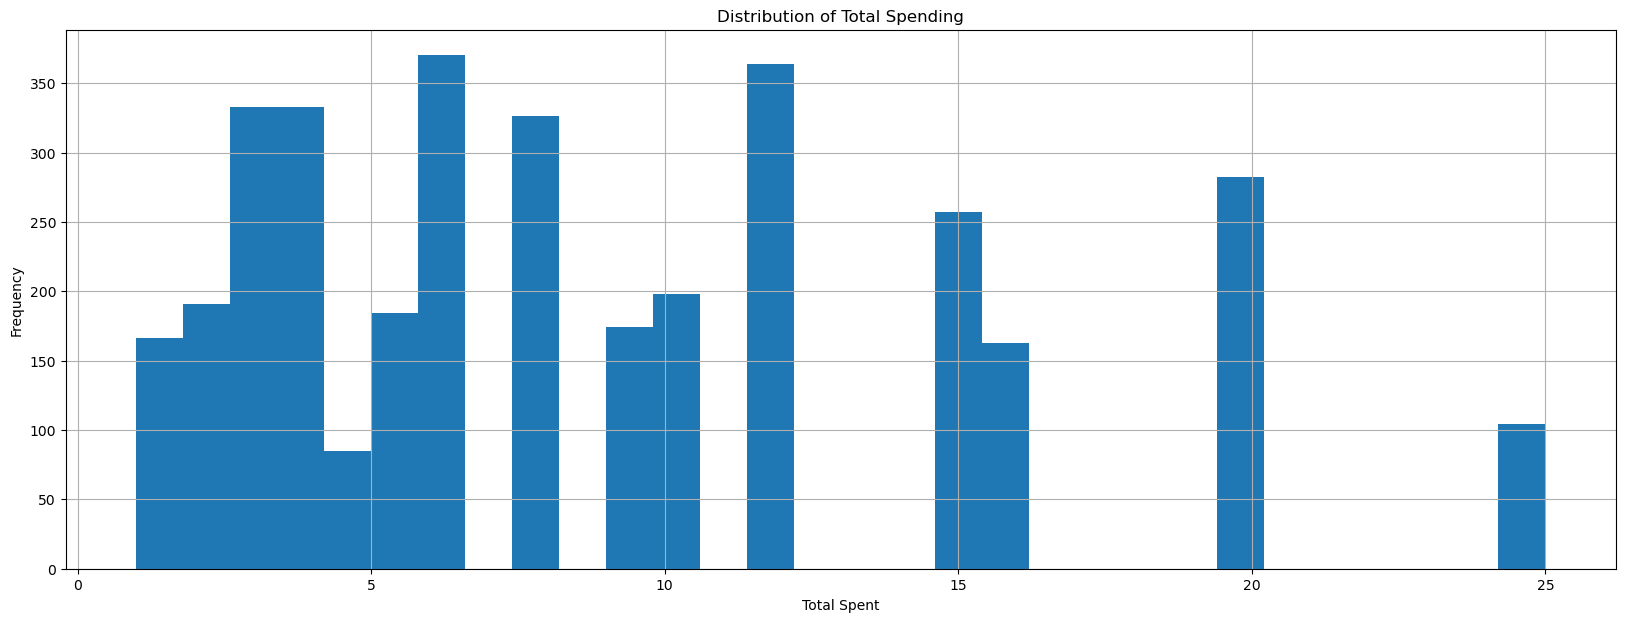

In [1519]:
df["Total Spent"].hist(bins=30)

plt.title("Distribution of Total Spending")

plt.xlabel("Total Spent")

plt.ylabel("Frequency")

<Axes: >

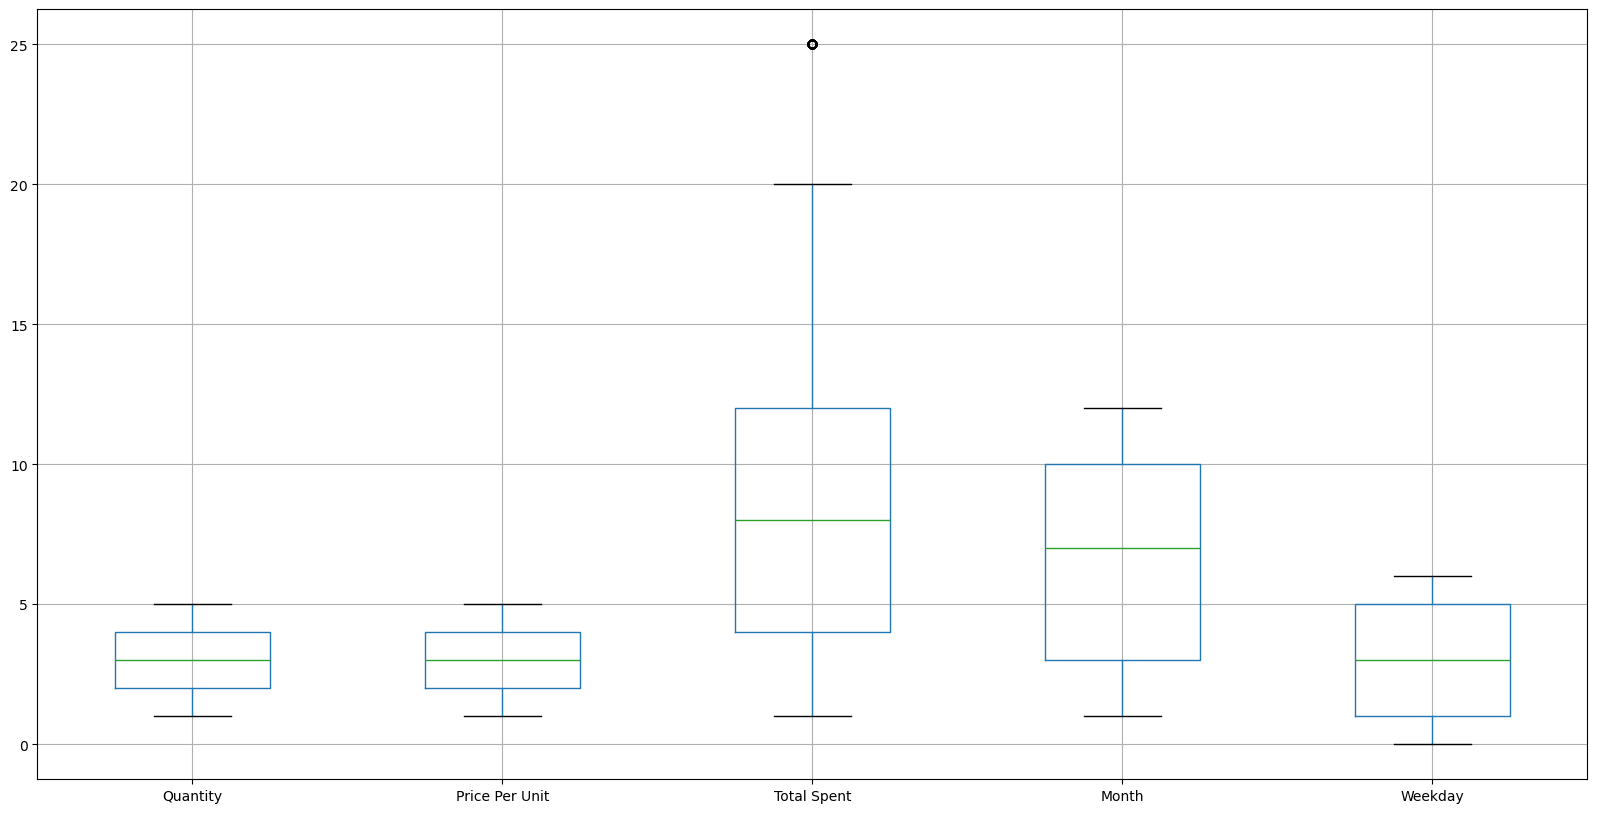

In [1522]:
df.boxplot(figsize=(20,10))

In [1526]:
corr = df.corr(numeric_only=True)

corr

,Quantity,Price Per Unit,Total Spent,Month,Weekday
Quantity,1.000000,0.007262,0.699180,-0.015299,0.000138
Price Per Unit,0.007262,1.000000,0.651428,-0.017546,0.001500
Total Spent,0.699180,0.651428,1.000000,-0.013860,0.000061
Month,-0.015299,-0.017546,-0.013860,1.000000,0.021530
Weekday,0.000138,0.001500,0.000061,0.021530,1.000000


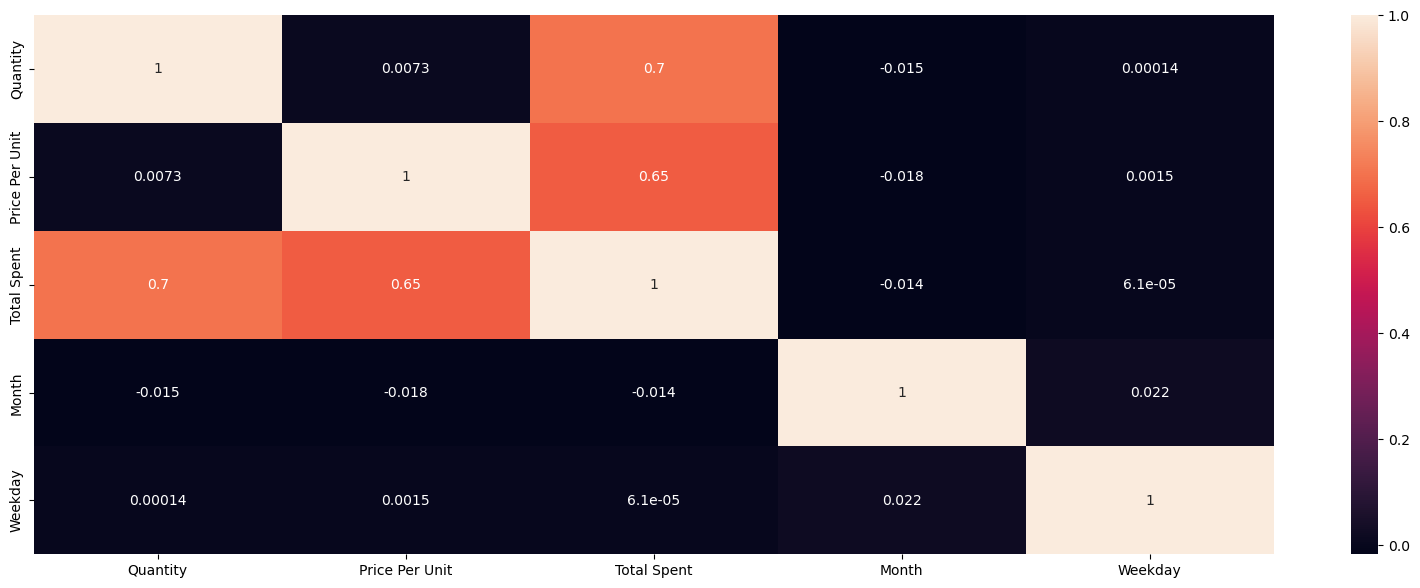

In [1527]:
sns.heatmap(corr, annot = True)

plt.rcParams['figure.figsize'] = (20,7)

plt.show()

| Correlation | Meaning                        |
| ----------: | ------------------------------ |
|         1.0 | Perfect positive relationship  |
|         0.8 | Strong positive relationship   |
|         0.5 | Moderate positive relationship |
|           0 | No linear relationship         |
|        -0.5 | Moderate negative relationship |
|        -0.8 | Strong negative relationship   |
|        -1.0 | Perfect negative relationship  |